# WOOD: corrected training and evaluation

This notebook uses the Python modules in the project folder as the single source of truth. The historical version is preserved in `notebooks/WOOD_original.ipynb`. Run from top to bottom. Training creates a new checkpoint; the original checkpoint is unchanged.


In [5]:
pip install mir_eval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 1.8 MB/s eta 0:00:00


## Setup
In Colab, select a GPU runtime and copy the entire project folder to Drive. Edit `PROJECT` below if necessary. Locally, open this notebook with the project virtual environment as its kernel.


In [1]:
from pathlib import Path
import os
import subprocess

repo = Path("/content/WOOD_MPE")

if not repo.exists():
    subprocess.run([
        "git", "clone",
        "https://github.com/xiaohet/WOOD_MPE.git",
        str(repo)
    ], check=True)
else:
    subprocess.run([
        "git", "-C", str(repo), "pull", "--ff-only"
    ], check=True)

os.chdir(repo)

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Verify device and regression checks
`auto` uses an available supported accelerator and otherwise CPU. An explicit CUDA selection fails if unavailable.


In [23]:
from wood.config import get_device
print('Device:', get_device())
subprocess.run([sys.executable, '-m', 'pytest', '-q'], check=True)


Device: cuda


CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', '-q'], returncode=0)

## Train
The default split reserves training songs for validation. Thresholds are selected on complete validation songs after training. Use a new output folder for each experiment. For a short pipeline check set epochs to 1 and add `--max-batches 1 --thresholds 0.5`; that does not produce a useful trained model.


In [6]:
from wood.config import get_device

!python train.py \
    --device get_device() \
    --data "/content/drive/MyDrive/WOOD_MPE/Data/train" \
    --test-data "/content/drive/MyDrive/WOOD_MPE/Data/test" \
    --output "/content/drive/MyDrive/WOOD_MPE/runs/github_run_001"

Excluded exact test-audio duplicates: ['/content/drive/MyDrive/WOOD_MPE/Data/train/12']
Loading training and validation features...
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is to

## Training curves


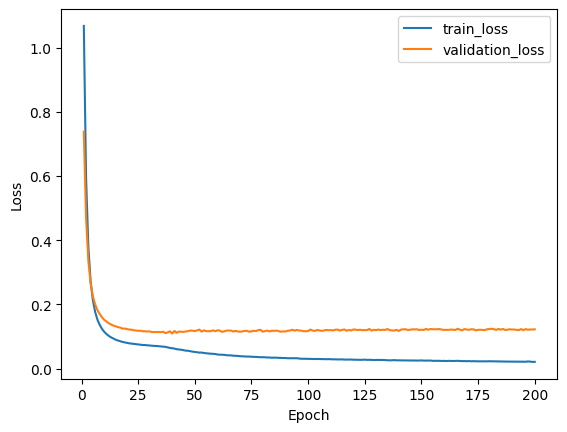

In [10]:
import json
import matplotlib.pyplot as plt
RUN = '/content/drive/MyDrive/WOOD_MPE/runs/notebook'
history = json.loads((Path(RUN) / 'history.json').read_text())
for key in ('train_loss', 'validation_loss'):
    plt.plot([r['epoch'] for r in history], [r[key] for r in history], label=key)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Evaluate all test songs
This uses saved validation thresholds and reports per-song and macro-averaged frame F1, note F1 and offset-aware note F1.


In [19]:
!python evaluate.py \
--checkpoint "/content/drive/MyDrive/WOOD_MPE/runs/notebook/best.pt" \
--data "/content/drive/MyDrive/WOOD_MPE/Data/test" \
--output "/content/drive/MyDrive/WOOD_MPE/runs/notebook/test_metrics.json"

/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
03 {'frame_precision': 0.00870195794053662, 'frame_recall': 0.005061155630535639, 'frame_f1': 0.0064, 'note_precision': 0.0007251631617113851, 'note_recall': 0.014925373134328358, 'note_f1': 0.0013831258644536651, 'note_with_offset_precision': 0.0, 'note_with_offset_recall': 0.0, 'note_with_offset_f1': 0.0}
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
11 {'frame_precision': 0.03164954936072102, 'frame_recall': 0.015151515151515152, 'frame_f1': 0.020492637578883085, 'note_precision': 0.00041919932928107315, 'note_recall': 0.006666666666666667, 'note_f1': 0.0007887990534411358, 'note_with_offset_precision': 0.0, 'note_with_offset_recall': 0.0, 'note_with_offset_f1': 0.0}
/usr/local/lib/python3.13/dist-packages/librosa/core/spectr

## Inspect one song


/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(


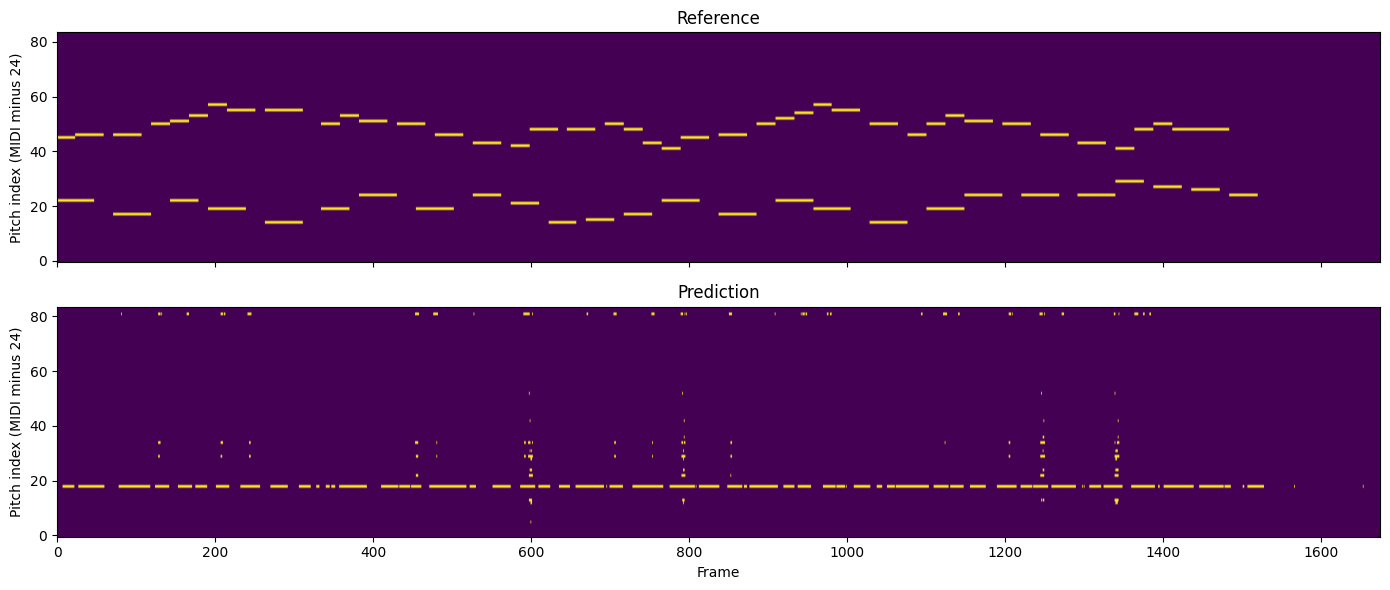

In [22]:
from wood.engine import load_checkpoint
from wood.data import load_song, song_folders
from wood.decoding import predict_song
device = get_device()
model, cfg, checkpoint = load_checkpoint(f'{RUN}/best.pt', device)
song = load_song(song_folders('/content/drive/MyDrive/WOOD_MPE/Data/test')[0], cfg)
th = checkpoint['thresholds']
pred = predict_song(model, song, cfg, device, th['onset'], th['offset'])
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, data, title in zip(axes, [song['frame'], pred['frame']], ['Reference', 'Prediction']):
    ax.imshow(data.T, aspect='auto', origin='lower')
    ax.set_title(title)
    ax.set_ylabel('Pitch index (MIDI minus 24)')
axes[-1].set_xlabel('Frame')
plt.tight_layout()
plt.show()
